# Description of Notebook
- This notebook covers code related to Random Forest and XGBoost Model creation as well as evaluation and analysis.

## Model Creation
- Input:
    - processed training data 
    - Target feature: RUL of each unit(remaining cycles; max_cycle - current_cycle = remaining_cycles)
- Output: 
    - Random Forest Model
    - XGBoost Model

## Model Evaluation
- Input:
    - Model
    - Test data
- Output:
    - RMSE for each model
    - MAE for each model
    - Forecast error over time visualization for each model
    - Residual Analysis for each model
    - Feature Importance Analysis (if applicable for models)
    - Comparison of at least 2 forecasting horizons

## Data Preprocessing Here

In [1]:
from collections.abc import Hashable, Mapping
import numpy as np
import pandas as pd
from IPython.display import display

In [4]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Placeholder for future preprocessing pipeline steps."""
    return df.copy()


def _coefficient_of_variation(series: pd.Series) -> float:
    """Return abs(std / mean), or infinity when the mean is effectively zero."""
    mean = series.mean()
    if pd.isna(mean) or np.isclose(mean, 0.0):
        return np.inf

    std = series.std()
    if pd.isna(std):
        return np.inf

    return float(abs(std / mean))


def drop_low_cv_sensors(
    data_dict: Mapping[Hashable, pd.DataFrame],
    threshold: float = 0.1,
) -> tuple[dict[Hashable, pd.DataFrame], list[str]]:
    """Drop sensors whose coefficient of variation is below the threshold across all datasets.

    Args:
        data_dict: Mapping of dataset ids to pandas DataFrames. Sensor columns are
            expected to follow the "Sensor <n>" naming convention, while all other
            columns such as unit ids, cycle counts, settings, RUL, and dataset labels
            are preserved.
        threshold: Minimum coefficient of variation required to keep a sensor.

    Returns:
        A tuple containing:
        - a copied dictionary of DataFrames with globally low-CV sensor columns removed
        - a sorted list of sensor column names that were dropped

    A sensor is removed only if its coefficient of variation, computed as abs(std / mean),
    is below ``threshold`` in every DataFrame where that sensor exists.
    """
    filtered_data = {key: df.copy() for key, df in data_dict.items()}

    sensor_cols = sorted(
        {
            col
            for df in filtered_data.values()
            for col in df.columns
            if col.startswith("Sensor")
        },
        key=lambda name: int(name.split()[1]),
    )

    sensors_to_drop: list[str] = []

    for sensor in sensor_cols:
        cv_values = [
            _coefficient_of_variation(df[sensor])
            for df in filtered_data.values()
            if sensor in df.columns
        ]

        if cv_values and all(cv < threshold for cv in cv_values):
            sensors_to_drop.append(sensor)

    for df in filtered_data.values():
        present_sensors = [sensor for sensor in sensors_to_drop if sensor in df.columns]
        if present_sensors:
            df.drop(columns=present_sensors, inplace=True)

    return filtered_data, sensors_to_drop

def compute_RUL(
    data_dict: Mapping[Hashable, pd.DataFrame]
) -> dict[Hashable, pd.DataFrame]:
    """Compute the RUL for each row in the datasets and add it as a new column.
        Args:
        data_dict: Mapping of dataset ids to pandas DataFrames.

    Returns:
        - a copied dictionary of DataFrames with RUL column
     RUL column is computed for each time step of each unit.
    """
    for i in data_dict:
        df = data_dict[i].copy()
        df["RUL"] = df.groupby("Unit Number")["Time, In Cycles"].transform(lambda x: x.max() - x)
        df["Dataset"] = f"FD00{i}" # adding a column to identify which dataset each row belongs to for combined analysis
        data_dict[i] = df
    return data_dict

def compute_lags(
        data_dict: Mapping[Hashable, pd.DataFrame],
        sensor_cols: list[str],
        lags: list[int]
) -> dict[Hashable, pd.DataFrame]:
        """Compute lag features for specified sensor columns and lags, and add them as new columns.
            Args:
            data_dict: Mapping of dataset ids to pandas DataFrames.
            sensor_cols: List of sensor column names to compute lags for.
            lags: List of integer lag values to compute.

        Returns:
            A dictionary of DataFrames with the computed lag features added as new columns.
        Lag features are computed for each time step of each unit, and lagged values are aligned with the current time step."""

        lagged_data = {key: df.copy() for key, df in data_dict.items()}
        for i in data_dict:
            df = data_dict[i].copy()
            # creating lag features for each unit to avoid data leaks across units
            for lag in lags:
                df_lag = df.groupby("Unit Number")[sensor_cols].shift(lag)
                df_lag.columns = [f"{col}_lag{lag}" for col in sensor_cols]

                df = df.join(df_lag)
            lagged_data[i] = df.dropna()
        return lagged_data

def compute_window_features(
    data_dict: Mapping[Hashable, pd.DataFrame],
    sensor_cols: list[str],
    window_size: int
) -> dict[Hashable, pd.DataFrame]:
    """Compute strictly historical rolling window features for each sensor.
        Args:
        data_dict: Mapping of dataset ids to pandas DataFrames.
        sensor_cols: List of sensor column names to compute window features for.
        window_size: Integer size of the rolling window.
    Returns:
    A dictionary of DataFrames with the computed window features added as new columns.
    Window features are computed for each time step of each unit, and rolling calculations are performed separately for each unit to avoid data leaks across units.
     Each row only uses prior time steps; the current time step is excluded from its own window.
     The new columns are named in the format "<sensor>_window{window_size}_mean" and "<sensor>_window{window_size}_std" for the mean and standard deviation features, respectively.
    """
    windowed_data = {key: df.copy() for key, df in data_dict.items()}
    for i in data_dict:
        df = data_dict[i].copy()
        # creating rolling window features for each unit to avoid data leaks across units
        for sensor in sensor_cols:
            history = df.groupby("Unit Number")[sensor].shift(1)
            df[f"{sensor}_window{window_size}_mean"] = history.groupby(df["Unit Number"]).transform(
                lambda x: x.rolling(window=window_size, min_periods=1).mean()
            )
            df[f"{sensor}_window{window_size}_std"] = history.groupby(df["Unit Number"]).transform(
                lambda x: x.rolling(window=window_size, min_periods=1).std()
            )
        windowed_data[i] = df.dropna()
    return windowed_data

def parse_data() -> dict[int, pd.DataFrame]:
    """Parse the original CMAPSS datasets from the text files and return a dictionary of DataFrames.
    """
    data_dict = {}
    for i in range(1,5):
        df = pd.read_csv(f"CMAPSSData/train_FD00{str(i)}.txt", sep=" ", header=None)
        df = df.drop(columns=[26, 27])  # Remove the last two empty columns
        df.columns = ["Unit Number", "Time, In Cycles", "Setting 1", "Setting 2", "Setting 3"] + [f"Sensor {i}" for i in range(1, 22)]
        data_dict[i] = df
    return data_dict

def clip_RUL(data_dict: Mapping[Hashable, pd.DataFrame], max_RUL: int = 125) -> dict[Hashable, pd.DataFrame]:
    """Clip the RUL values in the datasets to a maximum value.

    Args:
        data_dict: Mapping of dataset ids to pandas DataFrames, each containing an "RUL" column.
        max_RUL: Maximum RUL value to clip to. Any RUL values above this will be set to max_RUL.

    Returns:
        A dictionary of DataFrames with the RUL values clipped to the specified maximum.
    """
    clipped_data = {key: df.copy() for key, df in data_dict.items()}
    for key, df in clipped_data.items():
        if "RUL" in df.columns:
            df["RUL"] = df["RUL"].clip(upper=max_RUL)
    return clipped_data

def pipeline_A(data_dict: Mapping[Hashable, pd.DataFrame]) -> dict[Hashable, pd.DataFrame]:
    """Example pipeline that applies the preprocessing steps in sequence."""
    processed_data, dropped_sensors = drop_low_cv_sensors(data_dict, threshold=0.05)
    processed_data = compute_RUL(processed_data)
    sensor_cols = [col for col in data_dict[1].columns.drop(dropped_sensors) if col.startswith("Sensor")]
    processed_data = compute_lags(processed_data, sensor_cols=sensor_cols, lags=[1, 2, 3])
    processed_data = compute_window_features(processed_data, sensor_cols=sensor_cols, window_size=5)
    processed_data = clip_RUL(processed_data, max_RUL=125)
    return processed_data

In [5]:
# Load and preprocess the data
data_dict = parse_data()
processed_data = pipeline_A(data_dict)

## Evaluation Functions

In [6]:
import mlflow
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def forecast_error_overtime_plot(y_true, y_pred):
    plt.figure(figsize=(12, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect Prediction')
    plt.title("Predicted vs Actual RUL")
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.legend()
    plt.grid()
    plt.show()

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, predictions)
    mse = mean_absolute_error(y_test, predictions)
    print(f"Root Mean Squared Error: {rmse}")
    print(f"Mean Absolute Error: {mse}") 
    display(model.feature_importances_)
    forecast_error_overtime_plot(y_test, predictions)

def residuals_plot(residuals, y_pred):
    plt.figure(figsize=(12, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title("Residuals vs Predicted Values")
    plt.xlabel("Predicted RUL")
    plt.ylabel("Residuals")
    plt.grid()
    plt.show()

def residuals_histogram(residuals):
    plt.figure(figsize=(12, 6))
    sns.histplot(residuals, bins=30, kde=True)
    plt.title("Distribution of Residuals")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

def residuals_analaysis(y_true, y_pred):
    residuals = y_true - y_pred
    residuals_plot(residuals, y_pred)
    residuals_histogram(residuals)


## Model Training

In [8]:
# Enable MLflow autologging
mlflow.sklearn.autolog()

### Decision Tree Regressor

2026/04/23 20:57:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/conda/envs/ece447-26/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/23 20:57:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/conda/envs/ece447-26/lib/python3.11/si

Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0


array([1.85601622e-03, 1.10650824e-03, 0.00000000e+00, 0.00000000e+00,
       4.18364499e-03, 4.11516349e-03, 4.37537699e-03, 0.00000000e+00,
       0.00000000e+00, 3.72487278e-03, 1.85610895e-03, 0.00000000e+00,
       4.08047298e-03, 3.24573764e-03, 2.00735335e-03, 4.86736361e-03,
       0.00000000e+00, 7.31066286e-04, 0.00000000e+00, 0.00000000e+00,
       1.78872222e-03, 3.51560391e-03, 0.00000000e+00, 1.94859661e-03,
       2.30168039e-03, 2.25460803e-03, 0.00000000e+00, 5.92064861e-05,
       2.13993070e-03, 1.03277037e-03, 0.00000000e+00, 2.58078737e-03,
       2.24031730e-03, 1.50730561e-03, 2.52225922e-03, 0.00000000e+00,
       6.09755769e-04, 0.00000000e+00, 0.00000000e+00, 1.08397356e-03,
       2.05136444e-03, 0.00000000e+00, 1.52965308e-03, 2.05643454e-03,
       2.95176664e-03, 0.00000000e+00, 0.00000000e+00, 1.31027605e-03,
       2.22815652e-03, 0.00000000e+00, 1.72600738e-03, 3.46879619e-03,
       9.05576814e-04, 2.15929818e-03, 0.00000000e+00, 4.74116235e-04,
      

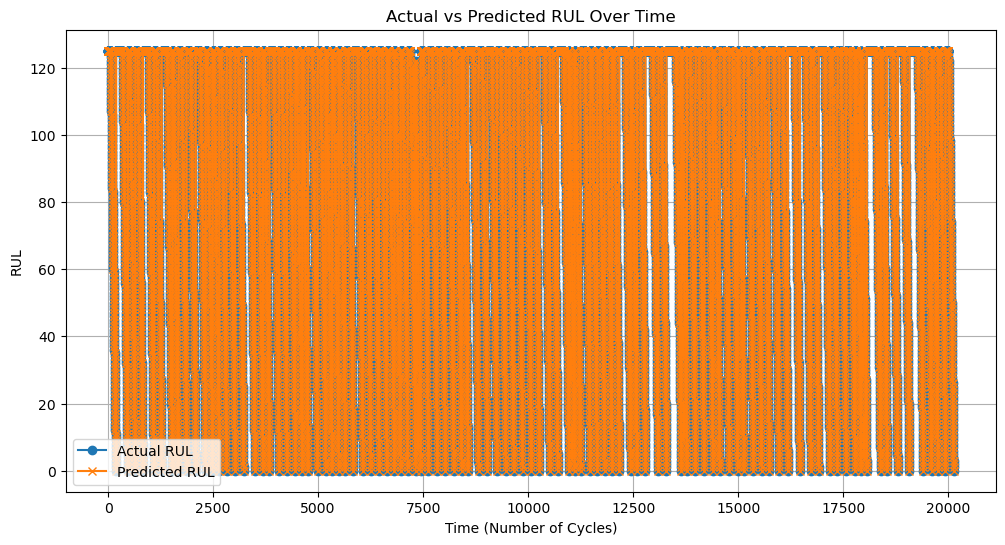

2026/04/23 20:57:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/conda/envs/ece447-26/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


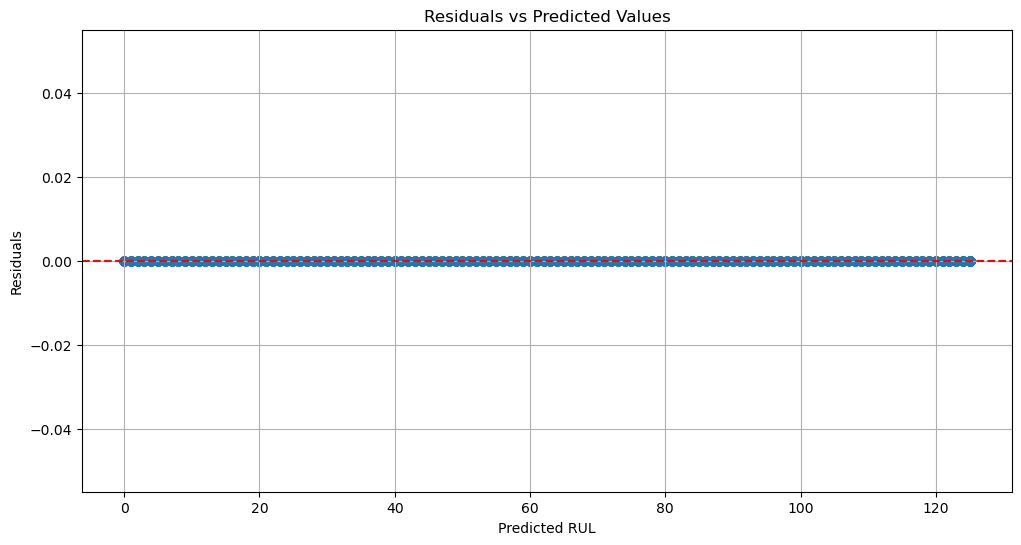

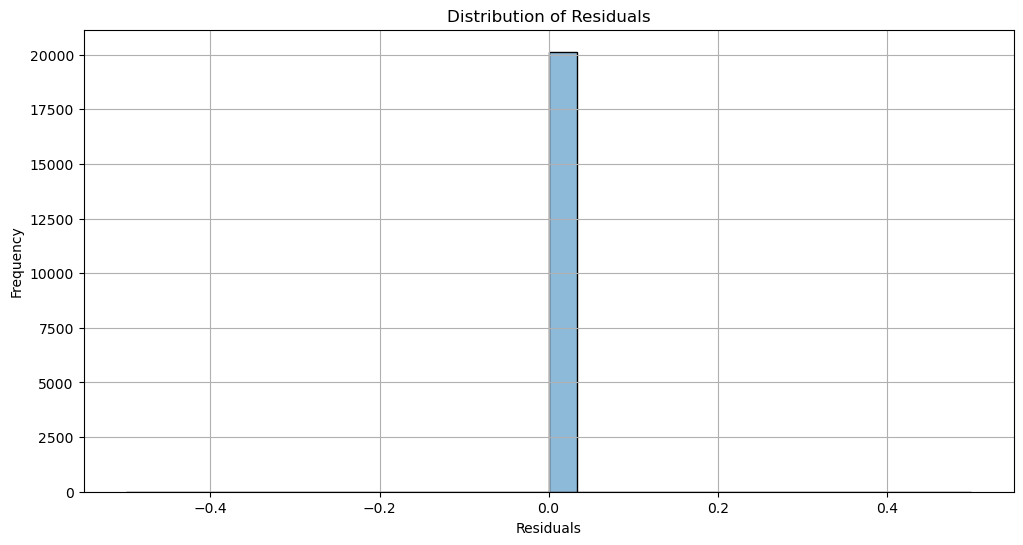

Logged data and model in run e912c0c8225945b385e5f56511b7e77e


In [9]:
def train_decision_tree(X_train, y_train):
    # adjust hyperparameters as needed
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    return model

# Prepare the decision tree data
X_train = processed_data[1].drop(columns=["Unit Number", "Time, In Cycles", "RUL", "Dataset"])
y_train = processed_data[1]["RUL"]

# Start an MLflow run to track the Decision Tree Regressor model
with mlflow.start_run(run_name="Decision Tree Regressor") as dt_run:
    # Train the decision tree model
    model_dt = train_decision_tree(X_train, y_train)

    # Evaluate the decision tree model
    evaluate_model(model_dt, X_train, y_train)
    residuals_analaysis(y_train, model_dt.predict(X_train))
    run_id = mlflow.last_active_run().info.run_id
    print(f"Logged data and model in run {run_id}")

### Random Forest Regressor

In [ ]:
def train_random_forest(X_train, y_train):
    # adjust hyperparameters as needed
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

# Prepare the data for Random Forest
X_train = df_unit1.drop(columns=["Unit Number", "Time, In Cycles", "RUL"])
y_train = df_unit1["RUL"]

# Start a new MLflow run for Random Forest Regressor
with mlflow.start_run(run_name="Random Forest Regressor") as rf_run:
    # Train the Random Forest model
    model_rf = train_random_forest(X_train, y_train)
    # Evaluate Random Forest model
    evaluate_model(model_rf, X_train, y_train)
    residuals_analaysis(y_train, model_rf.predict(X_train))
    run_id = mlflow.last_active_run().info.run_id
    print(f"Logged data and model in run {run_id}")
    print("View results by running 'mlflow ui' and visiting http://localhost:5000")

### XGBoost Regressor

In [ ]:
def train_gradient_boosting(X_train, y_train):
    # adjust hyperparameters as needed
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    return model

# Prepare the data for Gradient Boosting
X_train = df_unit1.drop(columns=["Unit Number", "Time, In Cycles", "RUL"])
y_train = df_unit1["RUL"]

# Start a new MLflow run for Gradient Boosting Regressor
with mlflow.start_run(run_name="Gradient Boosting Regressor") as gb_run:
    # Train the Gradient Boosting model
    model_gb = train_gradient_boosting(X_train, y_train)

    # Evaluate the Gradient Boosting model
    evaluate_model(model_gb, X_train, y_train)
    residuals_analaysis(y_train, model_gb.predict(X_train))
    run_id = mlflow.last_active_run().info.run_id
    print(f"Logged data and model in run {run_id}")
    print("View results by running 'mlflow ui' and visiting http://localhost:5000")